In [3]:
import numpy as np
import librosa
import pywt

def extract_features(file_path, sr=22050, n_mfcc=13):

    y, _ = librosa.load(file_path, sr=sr, mono=True)

    # Log-Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    log_mel = librosa.power_to_db(mel)

    # MFCC
    mfcc = librosa.feature.mfcc(S=log_mel, sr=sr, n_mfcc=n_mfcc)

    # Spectral Contrast
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)

    # Wavelet
    coeffs, _ = pywt.cwt(y, np.arange(1, 32), 'morl', sampling_period=1/sr)
    wavelet_mean = np.mean(np.abs(coeffs), axis=1)
    wavelet_std = np.std(np.abs(coeffs), axis=1)

    features = np.concatenate([
        np.mean(mfcc, axis=1),
        np.std(mfcc, axis=1),
        np.mean(contrast, axis=1),
        wavelet_mean,
        wavelet_std
    ])

    return features

In [4]:
import os
import numpy as np
import librosa
import pywt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

base_path = 'trimmed_fixed'

X = []
y = []

for class_name in os.listdir(base_path):
    folder_path = os.path.join(base_path, class_name)
    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if file.lower().endswith('.wav'):
            file_path = os.path.join(folder_path, file)
            try:
                features = extract_features(file_path)
                X.append(features)
                y.append(class_name)
            except Exception as e:
                print(f"Error in {file}: {e}")

X = np.array(X)
y = np.array(y)

In [6]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

model.add(Dense(y_train.shape[1], activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 256)                 │          24,576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 66,118 (258.27 KB)

 Trainable params: 66,118 (258.27 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.2621 - loss: 1.7732 - val_accuracy: 0.2698 - val_loss: 1.6936
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3831 - loss: 1.5697 - val_accuracy: 0.3333 - val_loss: 1.6318
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4718 - loss: 1.4409 - val_accuracy: 0.3492 - val_loss: 1.6117
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5000 - loss: 1.3645 - val_accuracy: 0.3333 - val_loss: 1.5790
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5121 - loss: 1.2945 - val_accuracy: 0.3333 - val_loss: 1.5686
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5000 - loss: 1.2577 - val_accuracy: 0.3492 - val_loss: 1.6198
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5565 - loss: 1.1669 - val_accuracy: 0.3492 - val_loss: 1.5310
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5847 - loss: 1.1458 - val_accuracy: 0.3651 - val

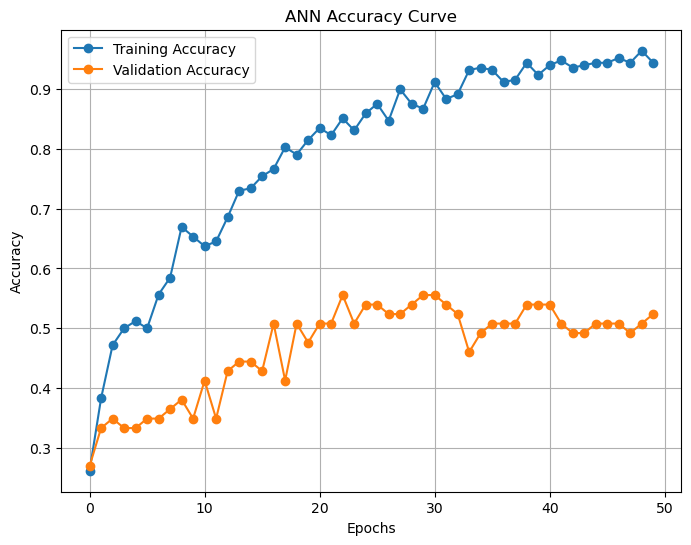

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')

plt.title("ANN Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.grid(True)

plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


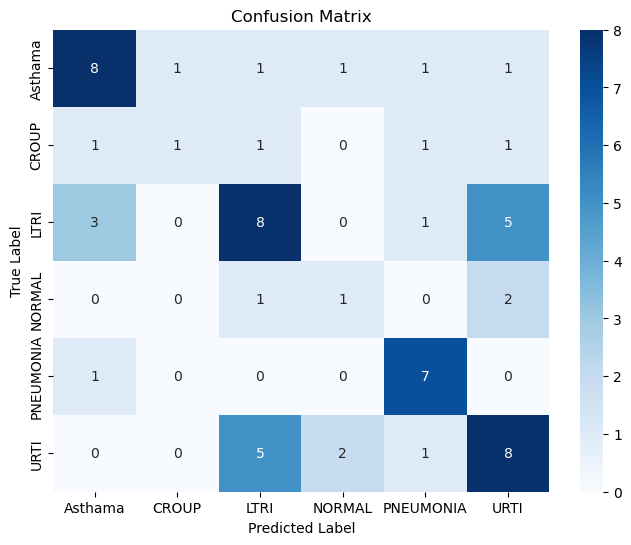

              precision    recall  f1-score   support

     Asthama       0.62      0.62      0.62        13
       CROUP       0.50      0.20      0.29         5
        LTRI       0.50      0.47      0.48        17
      NORMAL       0.25      0.25      0.25         4
   PNEUMONIA       0.64      0.88      0.74         8
        URTI       0.47      0.50      0.48        16

    accuracy                           0.52        63
   macro avg       0.50      0.49      0.48        63
weighted avg       0.52      0.52      0.51        63



In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict test data
y_pred = model.predict(X_test)

# Convert one-hot to class index
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=label_encoder.classes_
))